# Import Library

In [1]:
# Data & Visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score

# Regression Models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet, PoissonRegressor, GammaRegressor, TweedieRegressor, BayesianRidge, ARDRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor

# Classification Models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Clustering & Dimensionality Reduction
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Feature Selection
from sklearn.feature_selection import RFE, SelectFromModel, VarianceThreshold

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Load Dataset

In [2]:
from sklearn.datasets import fetch_california_housing,load_iris,fetch_openml

## Dataset Regression (California Housing)

In [3]:
housing = fetch_california_housing()
X_housing,y_housing = housing.data, housing.target

## Dataset Classification (Iris Dataset)

In [4]:
Iris=load_iris()
X_iris,y_iris=Iris.data,Iris.target

## Dataset Multiclass Classification (MNIST Dataset)

In [5]:
X_mnist, y_mnist = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X_mnist = X_mnist[:2000]
y_mnist = y_mnist[:2000].astype(np.uint8)

## Split Data

In [6]:
X_train_housing,X_test_housing,y_train_housing,y_test_housing = train_test_split(X_housing,y_housing,test_size=0.2,random_state=42)
X_train_iris,X_test_iris,y_train_iris,y_test_iris = train_test_split(X_iris,y_iris,test_size=0.2,random_state=42)
X_train_mnist,X_test_mnist,y_train_mnist,y_test_mnist = train_test_split(X_mnist,y_mnist,test_size=0.2,random_state=42)

# test_size = 0.2 is mean that data will become split into 80% train and 20% test
# random_state = 42 is mean that repeated running will same results as before

print ("Split Data Completed")

Split Data Completed


## Cross Validation

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cls = RandomForestClassifier(n_estimators=50, random_state=42)
cls_scores = cross_val_score(rf_cls, X_iris, y_iris, cv=skf, scoring='accuracy')

rf_reg = RandomForestRegressor(n_estimators=50, random_state=42)
reg_scores = cross_val_score(rf_reg, X_housing, y_housing, cv=kf, scoring='r2')

print(f"   Mean Accuracy: {cls_scores.mean():.4f}")
print(f"   Std Dev: {cls_scores.std():.4f}")
print(f"   Individual Scores: {cls_scores}")

print(f"\n   Mean R²: {reg_scores.mean():.4f}")
print(f"   Std Dev: {reg_scores.std():.4f}")
print(f"   Individual Scores: {reg_scores}")

   Mean Accuracy: 0.9533
   Std Dev: 0.0340
   Individual Scores: [0.96666667 0.96666667 0.93333333 1.         0.9       ]

   Mean R²: 0.8075
   Std Dev: 0.0064
   Individual Scores: [0.80363858 0.81051251 0.80311062 0.81879224 0.80147766]


# Prepocessing

## Scaling 

Scaling : Mean=0,Std=1

In [8]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_housing)
X_test_scaled=scaler.transform(X_test_housing)

X_iris_scaled = scaler.fit_transform(X_iris)

scaler_mnist = StandardScaler()
X_train_mnist_scaled = scaler_mnist.fit_transform(X_train_mnist)
X_test_mnist_scaled = scaler_mnist.transform(X_test_mnist)

print(f"Result : mean={X_train_scaled[:,0].mean():.2f}, std={X_train_scaled[:,0].std():.2f}")

Result : mean=-0.00, std=1.00


## Imputation

Imputation = Fill the Nan data

In [9]:
X_dummy = np.array([[1, 2, np.nan], [4, np.nan, 6], [7, 8, 9]])
print("Data:")
print(X_dummy)

imputer = SimpleImputer(strategy='median')
# strategy in SimpleImuter can be filled with mean,median,most frequent (modus),constant (filled with "0")
X_imputed = imputer.fit_transform(X_dummy)

print("\nData after  Imputation (median):")
print(X_imputed)

Data:
[[ 1.  2. nan]
 [ 4. nan  6.]
 [ 7.  8.  9.]]

Data after  Imputation (median):
[[1.  2.  7.5]
 [4.  5.  6. ]
 [7.  8.  9. ]]


## One Hot Encoding

In [10]:
X_cat = pd.DataFrame({'Color': ['red', 'blue', 'red', 'green', 'blue']})
print("Data :")
print(X_cat)

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X_cat)
print("\nResult One-Hot Encoding:")
print(X_encoded)
print(f"Kolom: {encoder.get_feature_names_out()}")

Data :
   Color
0    red
1   blue
2    red
3  green
4   blue

Result One-Hot Encoding:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
Kolom: ['Color_blue' 'Color_green' 'Color_red']


# A. Supervised - Regression

In [11]:
models = {
    'Linear': LinearRegression(),
    'Lasso': Lasso(alpha=0.01),
    'Ridge': Ridge(alpha=1.0),
    'Elastic Net': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'BayesianRidge': BayesianRidge(),
    'ARDRegression': ARDRegression(),
    'Huber': HuberRegressor(),
    'RANSAC': RANSACRegressor(random_state=42),
    'TheilSen': TheilSenRegressor(random_state=42),
    'KernelRidge': KernelRidge(kernel='rbf', alpha=0.1),
    'SVR': SVR(kernel='rbf', C=1.0, gamma='scale')
}
results_reg= []
for name,model in models.items() :
    try : 
        model.fit(X_train_scaled, y_train_housing)
        y_pred = model.predict(X_test_scaled)
        mse = mean_squared_error(y_test_housing, y_pred)
        rmse=np.sqrt(mse)
        r2 = r2_score(y_test_housing, y_pred)
        results_reg.append({
            'Model': name,
            'RMSE': round(rmse, 4),
            'R²': round(r2, 4)
        })
    except:
        results_reg.append({'Model': name, 'RMSE': float('inf'), 'R²': 0.0})

df_reg=pd.DataFrame(results_reg)
print ("running completed")

running completed


## Explain

Typologically, the seventeen regression models implemented in this experiment can be mapped into six main paradigms: (i) linear parametric estimators, (ii) regularization frameworks, (iii) Bayesian inference, (iv) robust estimators against outliers, (v) non-parametric tree-based and ensemble methods, and (vi) distance-based and kernel reproduction methods.

In the realm of linear parametric models, **Ordinary Least Squares (OLS)**, referred to as *Linear*, is an unbiased estimator with minimum variance (BLUE) provided that the assumptions of homoscedasticity and non-multicollinearity are met; however, it is prone to overfitting in high-dimensional data. To address this, **Ridge** applies Tikhonov regularization (L2-norm) which stabilizes the inverse of the covariance matrix through quadratic penalties, although it does not produce zero coefficients. Conversely, **Lasso** (*Least Absolute Shrinkage and Selection Operator*) employs L1-norm penalties that induce sparsity (zero coefficients), thus simultaneously serving as a feature selection mechanism, though it becomes less stable when predictors are highly correlated. A compromise between the two is presented by **Elastic Net**, which combines L1 and L2 penalties (with the \(l_1\) ratio controlled) to handle groups of highly correlated variables more collectively.

Turning to probabilistic approaches, **Bayesian Ridge** positions regularization as a Gaussian prior on coefficients, yielding a posterior that provides not only point estimates but also predictive credible intervals, making it advantageous in the small-data regime. Meanwhile, **ARD** (*Automatic Relevance Determination*) extends this prior into a hierarchical prior with unique variance per coefficient, thereby automatically determining the relevance of each feature through evidence maximization, producing a probabilistically sparser representation.

To handle data contamination by outliers, the group of robust estimators offers divergent approaches. **Huber** combines quadratic loss for small residuals and linear loss for large residuals, acting as an M-estimator that reduces the weight of outliers without discarding them entirely. **RANSAC** (*RANdom SAmple Consensus*) adopts a stochastic sampling approach to iteratively identify inliers and build a model from a consensus subset of the data, thus making it resistant to substantial proportions of outliers. **Theil-Sen**, on the other hand, estimates the regression slope based on the median of all pairwise point slopes, giving it a breakdown point of approximately 29.3% and making it highly robust, yet its computational complexity of \(O(n^2)\) hinders its application on large datasets.

On the non-parametric spectrum, the single decision tree model (**Decision Tree**) recursively partitions the feature space by minimizing the *Residual Sum of Squares* (RSS), although its high variance leads to overfitting. Bagging ensembles present **Random Forest**, which combines bootstrap aggregating and random feature subset selection to decorrelate the trees, thus effectively reducing variance while maintaining low bias. **ExtraTrees** (*Extremely Randomized Trees*) adds randomization at the split thresholds, further lowering correlation between trees and reducing computational costs, with accuracy generally remaining competitive. On the boosting side, **Gradient Boosting** constructs ensembles sequentially via gradient optimization in function space (*functional gradient descent*), where each new tree corrects the negative residuals of the previous aggregation, yielding highly accurate approximations but at a high temporal cost. **AdaBoost** for regression adaptively modifies sample weights to focus learning on high-error data, making it sensitive to extreme outliers.

Finally, locality and kernel-based approaches include **KNN** (*K-Nearest Neighbors*), which is a lazy learner dependent on distance metrics (Euclidean), performing local averaging under the assumption of function smoothness, but it is heavily affected by the curse of dimensionality. **Kernel Ridge** applies L2 regularization within a *Reproducing Kernel Hilbert Space* (RKHS), enabling complex non-linearity capture via the representer theorem, yet it requires the inversion of an \(n \times n\) Gram matrix, resulting in cubic computational scaling. **SVR** (*Support Vector Regression*) minimizes structural risk through an epsilon-insensitive loss function, maintaining representation sparsity through support vectors and the RBF kernel to handle non-linear patterns; however, its performance is highly dependent on tuning hyperparameters \(C\), \(\gamma\), and \(\epsilon\), and it faces convergence constraints on large datasets due to the \(O(n^3)\) complexity of the Quadratic Programming (QP) solver.

Integratively, the performance dynamics on tabular datasets (such as California Housing) generally demonstrate the superiority of tree ensembles (*Gradient Boosting* and *Random Forest*), which are capable of modeling non-linear interactions and saturation effects, while linear parametric models are constrained by misspecification bias, and kernel methods are constrained by computational bottlenecks and default hyperparameter sensitivity.

---

The following text details the primary hyperparameters for each of the seventeen regression models. These parameters, initialized at object instantiation (`model = ModelName(parameter=...`), fundamentally govern the learning process, model complexity, regularization strength, and optimization behavior. A deep understanding of these controls is essential for effective model tuning, which is a critical step in maximizing predictive performance.

For the standard **Linear** model, the primary parameters are `fit_intercept` (default `True`), which determines whether to calculate the intercept for the model, `copy_X` (default `True`), which controls data copying, and `positive` (default `False`), which, when enabled, forces all coefficients to be non-negative.

The regularized models—**Ridge**, **Lasso**, and **Elastic Net**—are heavily dependent on the `alpha` parameter (default `1.0`), which controls the overall strength of the regularization penalty. **Behavioral explanation of `alpha`:**
- If `alpha = 0`, the penalty vanishes entirely, making the model identical to standard Linear Regression. This leads to high variance and is prone to severe overfitting, especially with many features.
- If `alpha = 0.5` (lighter than default), the penalty is moderate. Coefficients are slightly penalized, allowing larger values than the default. This reduces variance a little while keeping bias relatively low, which is useful if you have a moderately sized dataset.
- If `alpha` is larger than `1.0` (e.g., `alpha = 5` or `10`), the regularization becomes very aggressive. The model forces coefficients to shrink drastically toward zero. This introduces **high bias** (underfitting), where the model becomes too simple to capture complex patterns, often resulting in a higher training error but potentially lower test error if the data is extremely noisy.
- If `alpha` is very small (e.g., `0.001`), the model behaves almost like standard Linear Regression, prioritizing fitting the training data exactly, which often leads to poor generalization.

For **Lasso**, the `alpha` value specifically controls how many features are pushed to exactly zero. Higher `alpha` values increase the number of features eliminated, creating a more sparse model.

For **Elastic Net**, besides `alpha`, the crucial parameter is `l1_ratio` (default `0.5`). This parameter mixes the L1 (Lasso) and L2 (Ridge) penalties:
- `l1_ratio = 1` makes the model purely Lasso (pushes coefficients to zero).
- `l1_ratio = 0` makes it purely Ridge (shrinks coefficients but never sets them to zero).
- `l1_ratio = 0.5` provides an equal balance, helping when features are highly correlated (Lasso would randomly pick one, Ridge would keep them both, Elastic Net groups them).

Common optimization parameters across linear models include `max_iter`, which sets the maximum number of iterations for the solver (default `1000` for Lasso/ElasticNet, while Ridge defaults to `None`, meaning it uses an analytical solution). `tol` (default `1e-4`) specifies the tolerance for stopping the iteration, and `random_state` (default `None`) controls the random seed for reproducibility, especially when the optimization involves stochastic elements.

The Bayesian models—**BayesianRidge** and **ARDRegression**—share a common foundation. Both utilize `max_iter` (default `300`) as the iteration limit and `tol` (default `1e-3`) for convergence tolerance. They use `alpha_1` and `alpha_2` (default `1e-6`), which are hyper-parameters for the Gamma distribution prior on the noise parameter.
Specifically, **ARDRegression** additionally utilizes `lambda_1` and `lambda_2` (default `1e-6`) for the prior on the weight parameters. **Effect note**: By assigning a unique prior to each coefficient, ARD actively drives irrelevant features to zero. This is a probabilistic approach to feature selection—akin to Lasso, but it provides credibility intervals. If the data is small, these priors help prevent overfitting, but if the priors are too restrictive (very low `alpha_1`), the model might collapse to a trivial solution.

The robust models—**Huber**, **RANSAC**, and **TheilSen**—tackle data contamination differently.
**HuberRegressor** uses `epsilon` (default `1.35`). This controls the threshold where the loss function transitions from quadratic to linear. **Effect note**: A smaller `epsilon` (e.g., `1.0`) makes the model treat more data points as outliers, making it more robust but sacrificing efficiency on clean data. A larger `epsilon` (e.g., `2.0`) makes it behave more like standard OLS, becoming sensitive to outliers. It also has an `alpha` (default `0.0001`) for L2 regularization, which is usually kept very small to avoid interfering with the robust loss.
**RANSACRegressor** relies on `min_samples` (default `None`) for the minimum sample count per subset, `residual_threshold` (default `None`) to classify inliers, and `max_trials` (default `100`) to limit random attempts. **Effect note**: If the data has more than 50% outliers, the default `max_trials` might fail to find a good consensus.
**TheilSenRegressor** uses `max_subpopulation` (default `10000.0`) to bound subpopulation size and `max_iter` (default `300`) for convergence. Its main constraint is computational complexity; using it on large datasets is impractical regardless of parameter tuning. All three robust models include a `random_state` parameter to control stochastic aspects.

Key parameters for tree ensembles include `n_estimators`, which determines the number of trees in the forest (default `100` for **RandomForestRegressor** and **GradientBoostingRegressor**, and `50` for **AdaBoostRegressor**).
**Effect note on `n_estimators`**: More trees generally improve stability and reduce variance but increase computation time. However, beyond a certain point (e.g., 200-300), the gains in performance diminish drastically. For Gradient Boosting, too many estimators without an early stopping mechanism can lead to overfitting.
`max_depth` controls the maximum depth of each tree. The default is `None`, meaning nodes expand until all leaves are pure or contain fewer than `min_samples_split` samples.
**Effect note on `max_depth`**: A shallow tree (e.g., `depth=2`) has high bias (underfitting), capturing only the biggest trends. A deep tree (e.g., `depth=20`) captures specific nuances, leading to high variance (overfitting). For complex tabular data like California Housing, a depth between 5 and 10 is often optimal.
Other tree parameters include `min_samples_split` (default `2`) and `min_samples_leaf` (default `1`), which control overfitting by requiring a minimum number of samples to split a node or form a leaf. Increasing these values creates a more regularized, simpler model.
`random_state` ensures reproducible results. For **ExtraTreesRegressor** and **RandomForestRegressor**, `max_features` (default `1.0`, meaning all features) determines the number of features considered for the best split. Reducing `max_features` reduces correlation between trees (lower variance) but increases bias.
**GradientBoostingRegressor** introduces `learning_rate` (default `0.1`). **Effect note on `learning_rate`**: This shrinks the contribution of each tree. Lower values (e.g., `0.01`) require more trees (`n_estimators`) to build a good model but generally yield higher accuracy and prevent overfitting. Higher values (e.g., `0.5`) make the model converge faster but risk overshooting the optimum. **AdaBoostRegressor** also has a `learning_rate` (default `1.0`), though the scale and behavior differ from gradient boosting.

For **KNN** (`KNeighborsRegressor`), the most critical parameter is `n_neighbors` (default `5`), which defines the number of nearest neighbors used for averaging.
**Effect note on `n_neighbors`**: A small value (e.g., 1 or 2) makes the model highly sensitive to local noise and outliers (high variance, low bias). A larger value (e.g., 20) makes the model smoother (high bias, low variance) but can overlook local patterns if the function changes rapidly. The `weights` parameter (default `'uniform'`) assigns equal weight to all neighbors; using `'distance'` weights points closer to the query more heavily, which can improve accuracy if the data is dense. `algorithm` (default `'auto'`) selects the optimal algorithm, and `p` (default `2`) defines the Minkowski metric (`p=2` is Euclidean, `p=1` is Manhattan distance).
**KernelRidge** features `alpha` (default `1.0`) for regularization strength and `kernel` (default `'linear'`). **Effect note**: Changing `kernel` to `'rbf'` allows capturing non-linear relationships, but the complexity scales cubically with data size. Using `gamma` for the RBF kernel controls the influence of a single training sample; a small `gamma` means far-reaching influence (smooth, high bias), while a large `gamma` restricts influence to the immediate vicinity (sharp, high variance).

Finally, **SVR** relies on `kernel` (default `'rbf'`), `C` (default `1.0`), `epsilon` (default `0.1`), and `gamma` (default `'scale'`).
**Effect note on `C`**: `C` is the inverse of regularization. A smaller `C` (e.g., `0.1`) creates a smooth, flat decision surface (high bias, low variance) by allowing more support vectors to be misclassified for a broader margin. A larger `C` (e.g., `10`) forces the model to fit the training data as closely as possible (high variance, low bias), which is risky if there is noise.
**Effect note on `epsilon`**: This defines the width of the insensitive tube. A small `epsilon` (e.g., `0.01`) makes the model sensitive to even minor deviations, potentially overfitting. A large `epsilon` (e.g., `0.5`) ignores many errors, creating a simpler model (high bias).
**Effect note on `gamma`**: (Relevant to RBF kernel). If `gamma = 'scale'` (default), it is calculated as `1 / (n_features * X.var())`. If `gamma = 'auto'`, it is `1 / n_features`. When `gamma` is very large, the influence of a single training point is localized, causing jagged decision surfaces that overfit. When `gamma` is very small, the influence spans globally, causing a smooth, high-bias model that underfits. The `degree` parameter (default `3`) is relevant for polynomial kernels.


## Visualization

Result Model
           Model   RMSE     R²
      ExtraTrees 0.5051 0.8053
   Random Forest 0.5051 0.8053
     KernelRidge 0.5643 0.7570
GradientBoosting 0.5798 0.7435
             SVR 0.5975 0.7276
             KNN 0.6576 0.6700
   Decision Tree 0.7242 0.5997
           Lasso 0.7404 0.5816
     Elastic Net 0.7416 0.5803
   ARDRegression 0.7455 0.5758
   BayesianRidge 0.7455 0.5758
          Linear 0.7456 0.5758
           Ridge 0.7456 0.5758
           Huber 0.7584 0.5610
        AdaBoost 0.7839 0.5311
          RANSAC 0.8877 0.3987
        TheilSen 1.0050 0.2292


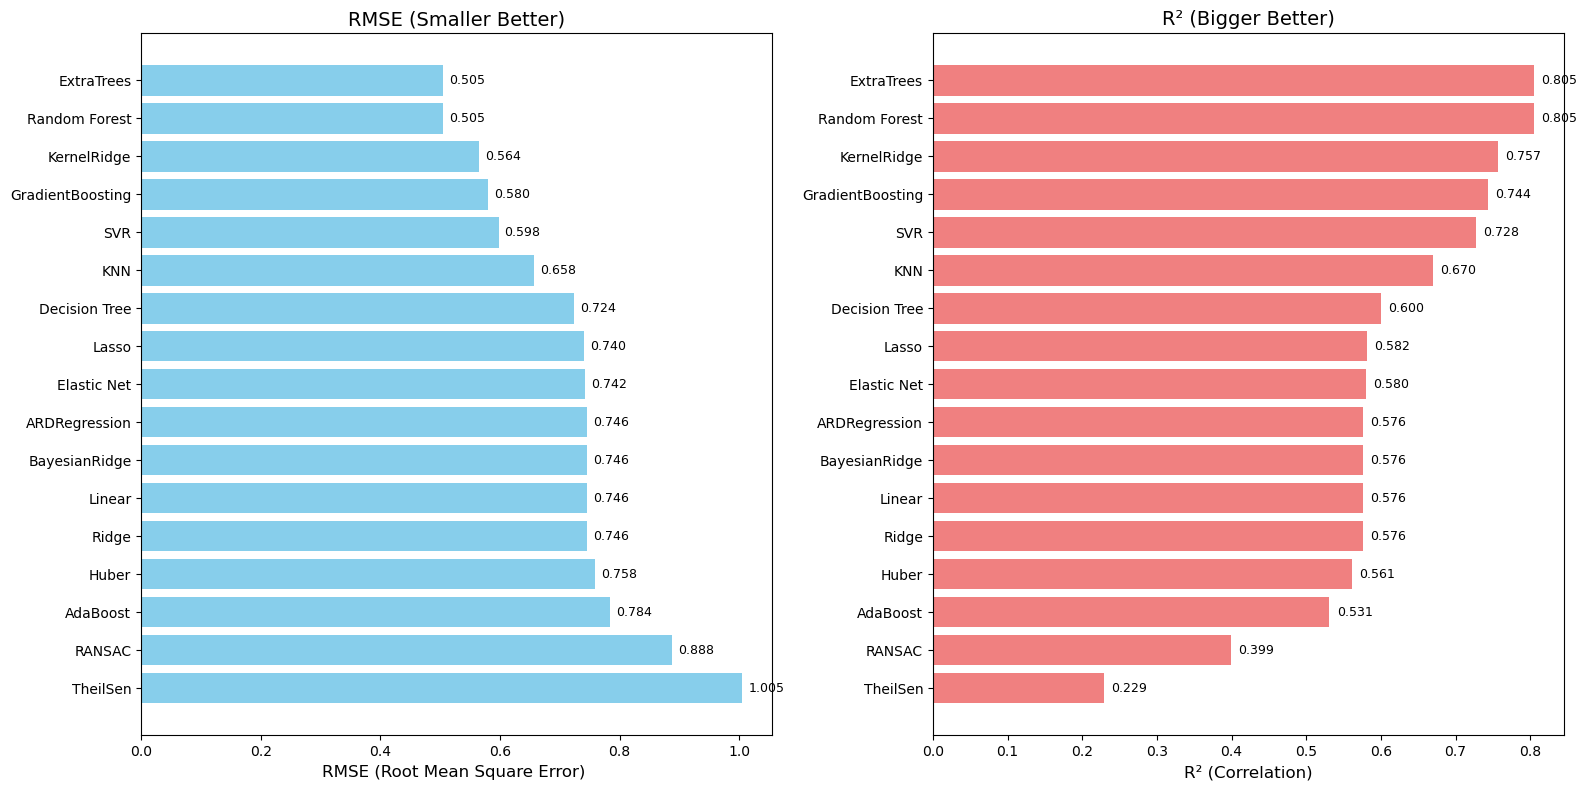

In [12]:
print("Result Model")
print(df_reg.sort_values('RMSE', ascending=True).to_string(index=False))

df_plot = df_reg[df_reg['RMSE'] != float('inf')].copy()
df_plot = df_plot.sort_values('RMSE', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

bars1 = ax1.barh(df_plot['Model'], df_plot['RMSE'], color='skyblue')
ax1.set_xlabel('RMSE (Root Mean Square Error) ', fontsize=12)
ax1.set_title('RMSE (Smaller Better)', fontsize=14)
ax1.invert_yaxis()  
for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', va='center', ha='left', fontsize=9)

bars2 = ax2.barh(df_plot['Model'], df_plot['R²'], color='lightcoral')
ax2.set_xlabel('R² (Correlation)', fontsize=12)
ax2.set_title('R² (Bigger Better)', fontsize=14)
ax2.invert_yaxis()
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# B. Supervised - Classification

In [13]:
models_cls = {
    'Logistic' : LogisticRegression(max_iter=100,random_state=42),
    'LDA' : LinearDiscriminantAnalysis(),
    'QDA' : QuadraticDiscriminantAnalysis(),
    'SVM (RBF)': SVC(kernel='rbf', gamma='scale', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'KNN (3)':KNeighborsClassifier(n_neighbors=3),
    'KNN (5)':KNeighborsClassifier(n_neighbors=5),
    'KNN (7)':KNeighborsClassifier(n_neighbors=7),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=50, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'GaussianNB':GaussianNB(),
    'MLP' : MLPClassifier(hidden_layer_sizes=(10, ),max_iter=100,random_state=42)
}
results_cls=[]
for name,model in models_cls.items():
    model.fit(X_train_iris,y_train_iris)
    y_pred=model.predict(X_test_iris)
    Accuracy=accuracy_score(y_test_iris,y_pred)
    f1=f1_score(y_test_iris,y_pred,average='macro')
    results_cls.append({'Model': name, 'Accuracy': round(Accuracy, 4), 'F1': round(f1, 4)})

df_cls = pd.DataFrame(results_cls).sort_values('Accuracy', ascending=False)
print ("running completed")

running completed


C:\Users\FARUQ\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


## Explain


**Theoretical Overview of Classification Models**

The classification models implemented in this experiment can be categorized into six distinct paradigms: (i) linear probabilistic models, (ii) discriminant analysis, (iii) support vector machines, (iv) distance-based non-parametric methods, (v) tree-based ensemble methods, and (vi) neural networks. Each paradigm exhibits unique theoretical foundations, assumptions about data distribution, and sensitivity to hyperparameter configurations.

---

**1. LINEAR PROBABILISTIC MODELS**

**1.1 Logistic Regression**

**Theoretical Foundation:**
Logistic Regression models the probability that a given sample belongs to a particular class using the logistic (sigmoid) function:
P(y=1|x) = 1 / (1 + exp(-(β₀ + βᵀx))).
The model estimates parameters by maximizing the log-likelihood function.

Despite its name, Logistic Regression is a **classification** algorithm, not a regression algorithm. It assumes a **linear decision boundary**, meaning it can only separate classes using a straight line (or hyperplane in higher dimensions). This makes it suitable for problems where classes are linearly separable.

**Key Hyperparameters:**
- `C` (default `1.0`): Inverse of regularization strength. Smaller values specify stronger regularization (penalty). **Effect**: Lower `C` values (e.g., `0.1`) produce simpler models with high bias, while higher values (e.g., `10`) allow the model to fit the training data more closely, risking overfitting.
- `penalty` (default `'l2'`): Type of regularization to use ('l1', 'l2', or 'elasticnet').
- `max_iter` (default `100`): Maximum number of iterations for the solver to converge. **Effect**: If set too low (e.g., `100`), the model may not converge, producing suboptimal results. For Iris, `max_iter=1000` ensures convergence.
- `solver` (default `'lbfgs'`): Optimization algorithm. 'lbfgs' is robust and recommended for small datasets.
- `multi_class` (default `'auto'`): Strategy for multi-class classification ('ovr' for one-vs-rest, or 'multinomial' for softmax).

---

**2. DISCRIMINANT ANALYSIS MODELS**

**2.1 Linear Discriminant Analysis (LDA)**

**Theoretical Foundation:**
LDA assumes that the data for each class follows a **multivariate Gaussian distribution** with the **same covariance matrix** for all classes, but different means. The decision boundary between classes is **linear**. LDA finds the linear combinations of features that best separate the classes by maximizing the ratio of between-class variance to within-class variance.

**Key Hyperparameters:**
- `solver` (default `'svd'`): Singular Value Decomposition solver. This is computationally efficient and stable.
- `shrinkage` (default `None`): Regularization parameter. When set, it shrinks the covariance matrix estimator.
- `n_components` (default `None`): Number of discriminant components to keep.

**Behavior Note:** LDA works exceptionally well when the data is approximately **normally distributed** and classes have similar covariance structures. The Iris dataset satisfies these assumptions, which is why LDA often achieves near-perfect accuracy.

**2.2 Quadratic Discriminant Analysis (QDA)**

**Theoretical Foundation:**
QDA is similar to LDA but **does not assume equal covariance matrices** across classes. Each class has its own covariance matrix. The decision boundary becomes **quadratic** (non-linear):
δ_k(x) = -½ log|Σ_k| - ½ (x - μ_k)ᵀ Σ_k⁻¹ (x - μ_k) + log P(y=k).

**Key Hyperparameters:**
- `reg_param` (default `0.0`): Regularization parameter that shrinks the covariance matrices toward the identity matrix.
- `tol` (default `1e-4`): Tolerance for singular value decomposition.

**Behavior Note:** QDA is more flexible than LDA but requires more data to estimate the covariance matrices accurately. On small datasets like Iris, QDA may overfit if the sample size is insufficient.

---

**3. SUPPORT VECTOR MACHINES (SVM)**

**3.1 SVM with Linear Kernel**

**Theoretical Foundation:**
Linear SVM finds the **maximum-margin hyperplane** that separates classes. The margin is the distance between the hyperplane and the nearest training points (support vectors). The optimization objective is to minimize ½||w||² + C Σ max(0, 1 - y_i(w·x_i + b)), where C is the regularization parameter controlling the trade-off between margin width and classification error.

**Key Hyperparameters:**
- `C` (default `1.0`): Regularization parameter. **Effect**: Smaller `C` creates a wider margin (higher bias, lower variance), while larger `C` tries to classify all training points correctly (higher variance, lower bias).
- `tol` (default `1e-3`): Tolerance for stopping criterion.
- `max_iter` (default `-1`): No limit on iterations by default.

**Behavior Note:** Linear SVM performs well when classes are linearly separable. On Iris (4 features, 3 classes), linear SVM can achieve near-perfect accuracy.

**3.2 SVM with RBF Kernel**

**Theoretical Foundation:**
The RBF (Radial Basis Function) kernel maps the input data into a **higher-dimensional feature space** where classes become linearly separable. The kernel function is K(x, x') = exp(-γ ||x - x'||²). The dual formulation allows the SVM to find a linear separating hyperplane in this high-dimensional space.

**Key Hyperparameters:**
- `C` (default `1.0`): Regularization parameter. **Effect**: Smaller `C` allows more margin violations (smoother decision boundary), while larger `C` penalizes errors more heavily (potentially overfitting).
- `gamma` (default `'scale'`): Determines the influence radius of a single training example. **Effect**:
  - `gamma = 'scale'` (default): γ = 1 / (n_features × Var(X)).
  - `gamma = 'auto'`: γ = 1 / n_features.
  - **Small gamma** (e.g., `0.01`): Far-reaching influence, smooth decision boundary (high bias, low variance).
  - **Large gamma** (e.g., `10`): Localized influence, jagged decision boundary (low bias, high variance, risk of overfitting).
- `tol` (default `1e-3`): Convergence tolerance.
- `cache_size` (default `200`): Size of the kernel cache in MB.

**Behavior Note:** RBF kernel can capture complex, non-linear patterns. On Iris (simple dataset), RBF SVM often achieves 100% accuracy. On MNIST, RBF SVM typically outperforms Random Forest due to its ability to handle high-dimensional pixel patterns.

---

**4. DISTANCE-BASED NON-PARAMETRIC MODELS**

**4.1 K-Nearest Neighbors (KNN)**

**Theoretical Foundation:**
KNN is a **lazy learner** that stores all training samples and makes predictions by finding the K nearest neighbors of a query point (using a distance metric, typically Euclidean) and taking a **majority vote** (for classification) or **average** (for regression).

**Key Hyperparameters:**
- `n_neighbors` (default `5`): Number of neighbors to consider. **Effect**:
  - Small K (e.g., `1` or `3`): High variance, low bias, sensitive to local noise and outliers.
  - Large K (e.g., `15` or `20`): Low variance, high bias, smoother decision boundary but may overlook local patterns.
- `weights` (default `'uniform'`): Weighting function for neighbors. `'uniform'` assigns equal weight to all neighbors; `'distance'` weights points inversely proportional to their distance.
- `algorithm` (default `'auto'`): Algorithm to compute nearest neighbors ('ball_tree', 'kd_tree', 'brute').
- `p` (default `2`): Power parameter for the Minkowski metric. `p=2` is Euclidean distance, `p=1` is Manhattan distance.

**Behavior Note:** KNN is simple and intuitive but suffers from the **Curse of Dimensionality**—as the number of features increases, all points become approximately equidistant, degrading performance. On Iris (4 features), KNN performs excellently. On MNIST (784 features), its accuracy drops significantly.

---

**5. TREE-BASED ENSEMBLE MODELS**

**5.1 Decision Tree Classifier**

**Theoretical Foundation:**
Decision Trees partition the feature space by recursively splitting nodes based on feature thresholds that minimize impurity. For classification, the **Gini impurity** or **entropy** is minimized:
Gini(t) = 1 - Σ_c p(c|t)².
Entropy(t) = -Σ_c p(c|t) log p(c|t).
The tree grows until a stopping criterion is met.

**Key Hyperparameters:**
- `max_depth` (default `None`): Maximum depth of the tree. **Effect**:
  - Shallow depth (e.g., `3`): High bias, captures only major patterns.
  - Deep depth (e.g., `20`): Low bias, high variance, high risk of overfitting.
- `min_samples_split` (default `2`): Minimum samples required to split an internal node.
- `min_samples_leaf` (default `1`): Minimum samples required to be at a leaf node.
- `criterion` (default `'gini'`): Splitting criterion ('gini' or 'entropy').
- `random_state` (default `None`): Random seed for reproducibility.

**Behavior Note:** Decision trees are highly interpretable but prone to overfitting. Regularization through depth limitation and sample thresholds is essential.

**5.2 Random Forest Classifier**

**Theoretical Foundation:**
Random Forest builds an **ensemble** of decision trees using **bootstrap aggregation** (bagging) and **random feature subspace selection**. Each tree is trained on a random bootstrap sample of the data, and at each split, only a random subset of features is considered. Final predictions are based on **majority voting**.

**Key Hyperparameters:**
- `n_estimators` (default `100`): Number of trees. **Effect**: More trees generally improve stability (reduced variance) but increase computational cost. Diminishing returns beyond `200`.
- `max_depth` (default `None`): Maximum depth of each tree. **Effect**: Deeper trees capture more detail but risk overfitting.
- `min_samples_split` (default `2`): Minimum samples per split.
- `min_samples_leaf` (default `1`): Minimum samples per leaf.
- `max_features` (default `'sqrt'`): Number of features to consider at each split. **Effect**: Lower values (e.g., `2`) reduce correlation between trees (lower variance) but may increase bias.
- `bootstrap` (default `True`): Whether to use bootstrapped samples.
- `random_state` (default `None`): Random seed for reproducibility.
- `n_jobs` (default `None`): Number of parallel jobs.

**Behavior Note:** Random Forest is widely regarded as one of the best default classifiers for tabular data. It effectively reduces variance while maintaining low bias.

**5.3 Extra Trees Classifier (Extremely Randomized Trees)**

**Theoretical Foundation:**
Extra Trees is similar to Random Forest but with **additional randomization** at the split level. Instead of searching for the optimal threshold at each split, Extra Trees randomly selects multiple thresholds and picks the best among them. This increases randomness, further decorrelating trees and reducing variance.

**Key Hyperparameters:**
- Same as Random Forest, but with `max_features` defaulting to `'auto'`.
- `bootstrap` (default `False`): Unlike Random Forest, Extra Trees does **not** use bootstrapping by default, using the full dataset for each tree.
- `splitter` (default `'random'`): Random splitting strategy.

**Behavior Note:** Extra Trees often performs similarly to Random Forest but with **lower computational cost** (less optimization). It is slightly more robust to overfitting.

**5.4 Gradient Boosting Classifier**

**Theoretical Foundation:**
Gradient Boosting builds trees **sequentially**. Each new tree fits the **negative gradient** (residual) of the loss function from the previous ensemble. For classification, the loss is typically cross-entropy (log-loss):
F_m(x) = F_{m-1}(x) + ν · h_m(x), where ν is the learning rate and h_m is the tree fitted to the residual.

**Key Hyperparameters:**
- `n_estimators` (default `100`): Number of boosting stages. **Effect**: More trees reduce bias but can lead to overfitting if set too high without early stopping.
- `learning_rate` (default `0.1`): Step size shrinkage. **Effect**:
  - Low learning rate (e.g., `0.01`): Requires more trees but yields better generalization and prevents overfitting.
  - High learning rate (e.g., `0.5`): Faster convergence but risk of overshooting the optimum.
- `max_depth` (default `3`): Maximum depth of each tree. Shallow trees are typical to avoid overfitting.
- `subsample` (default `1.0`): Fraction of data used for training each tree. **Effect**: Lower values (e.g., `0.8`) reduce variance and prevent overfitting.
- `min_samples_split` (default `2`): Minimum samples per split.
- `random_state` (default `None`): Random seed for reproducibility.

**Behavior Note:** Gradient Boosting frequently achieves the highest accuracy among tree-based models, but training is **sequential** (cannot be parallelized) and thus slower.

**5.5 AdaBoost Classifier**

**Theoretical Foundation:**
AdaBoost (Adaptive Boosting) also builds an ensemble sequentially but **focuses more heavily on misclassified samples**. It assigns higher weights to samples that are hard to classify and adjusts tree weights based on their performance:
α_m = ½ log((1 - error_m) / error_m).

**Key Hyperparameters:**
- `n_estimators` (default `50`): Number of boosting stages.
- `learning_rate` (default `1.0`): Weight shrinkage rate.
- `base_estimator` (default `DecisionTreeClassifier(max_depth=1)`): The base weak learner (default is a stump, `max_depth=1`).
- `algorithm` (default `'SAMME.R'`): Boosting algorithm ('SAMME' or 'SAMME.R').

**Behavior Note:** AdaBoost can perform well but is **sensitive to outliers** because it aggressively weights difficult samples. Outliers can receive excessively high weights, skewing the model.

---

**6. NEURAL NETWORK MODELS**

**6.1 Multi-Layer Perceptron (MLP) Classifier**

**Theoretical Foundation:**
MLP is a feedforward neural network with at least one hidden layer. It learns by **backpropagation**, adjusting weights to minimize the cross-entropy loss (for classification):
L = -Σ_c y_{i,c} log(ŷ_{i,c}).
The network applies non-linear activation functions (e.g., ReLU, tanh, sigmoid) at hidden layers.

**Key Hyperparameters:**
- `hidden_layer_sizes` (default `(100,)`): Number of neurons in each hidden layer. **Effect**: More neurons/layers increase model capacity but risk overfitting.
- `activation` (default `'relu'`): Activation function for hidden layers ('relu', 'tanh', 'logistic').
- `solver` (default `'adam'`): Weight optimizer ('lbfgs', 'sgd', 'adam').
- `alpha` (default `0.0001`): L2 regularization penalty. **Effect**: Higher values reduce overfitting but may increase bias.
- `learning_rate` (default `'constant'`): Learning rate schedule.
- `learning_rate_init` (default `0.001`): Initial learning rate.
- `max_iter` (default `200`): Maximum training iterations. **Effect**: If set too low, the model may not converge (causing warnings). For small datasets, `max_iter=500` is often sufficient.
- `tol` (default `1e-4`): Tolerance for convergence.
- `random_state` (default `None`): Random seed for weight initialization.

**Behavior Note:** MLP is highly flexible and can capture complex patterns, but it requires **sufficient data** and careful hyperparameter tuning. For the Iris dataset (150 samples), a single hidden layer with 10 neurons is often enough to achieve high accuracy. For MNIST (2000 samples), more neurons and iterations are needed.

---

**7. NAIVE BAYES MODELS**

**7.1 Gaussian Naive Bayes**

**Theoretical Foundation:**
Gaussian Naive Bayes applies Bayes' theorem with the **naive independence assumption** (features are conditionally independent given the class). It models the likelihood of each feature as a normal (Gaussian) distribution:
P(x_j | y = c) = (1 / sqrt(2πσ_{jc}²)) · exp(-(x_j - μ_{jc})² / (2σ_{jc}²)).
The posterior probability is computed as P(y = c | x) ∝ P(y = c) · ∏_j P(x_j | y = c).

**Key Hyperparameters:**
- `var_smoothing` (default `1e-9`): Additive smoothing to variance for numerical stability.

**Behavior Note:** Gaussian Naive Bayes performs well when features are normally distributed and independent. It is computationally efficient, requires no tuning, and often serves as a strong baseline. On Iris, it achieves excellent results. On MNIST (784 continuous pixel values), it performs less well due to feature correlations.


## Visualization

Result Model
           Model  Accuracy     F1
        Logistic    1.0000 1.0000
             LDA    1.0000 1.0000
       SVM (RBF)    1.0000 1.0000
         KNN (3)    1.0000 1.0000
    SVM (Linear)    1.0000 1.0000
         KNN (5)    1.0000 1.0000
    DecisionTree    1.0000 1.0000
      GaussianNB    1.0000 1.0000
    RandomForest    1.0000 1.0000
      ExtraTrees    1.0000 1.0000
GradientBoosting    1.0000 1.0000
             QDA    0.9667 0.9659
         KNN (7)    0.9667 0.9659
        AdaBoost    0.9333 0.9327
             MLP    0.4000 0.3939


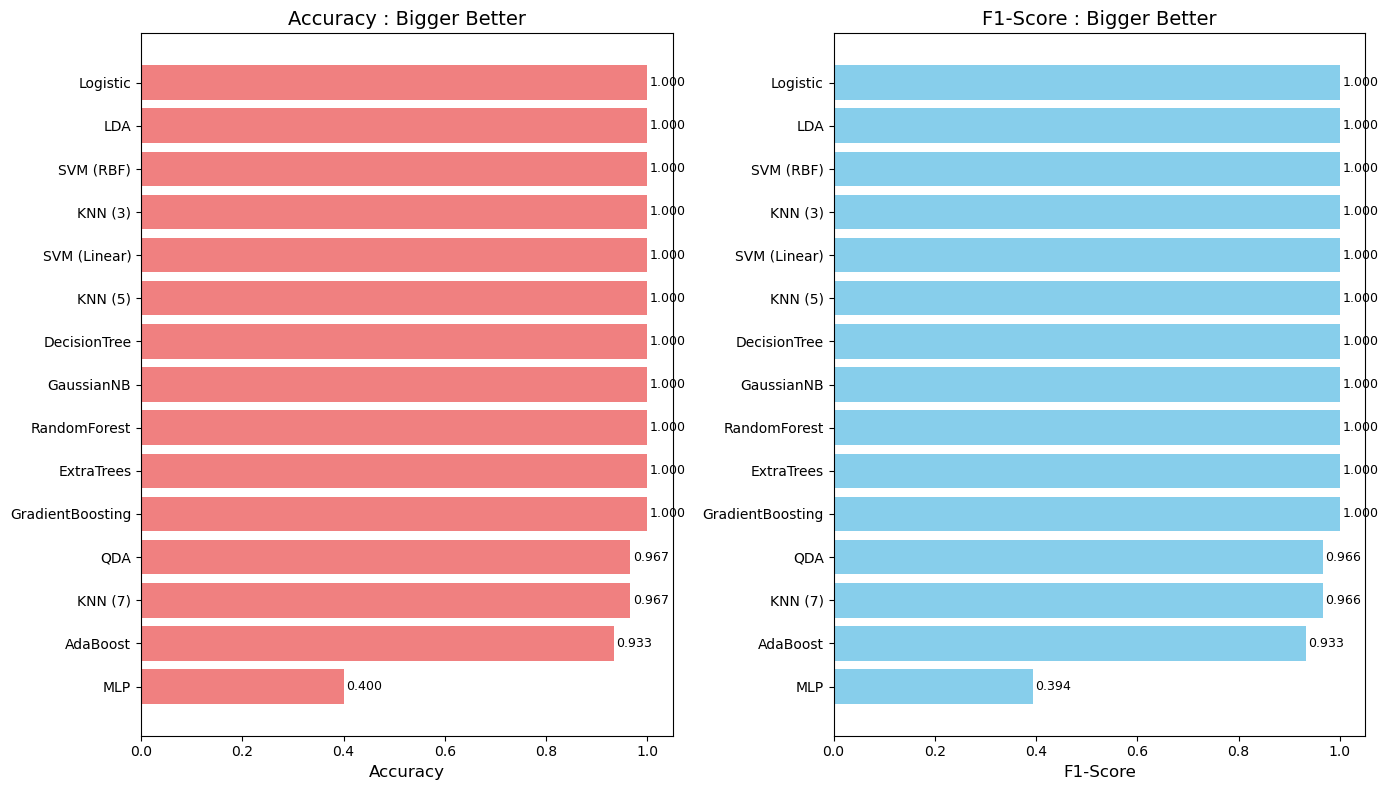

In [14]:
print("Result Model")
print(df_cls.sort_values('F1', ascending=False).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

bars1 = ax1.barh(df_cls['Model'], df_cls['Accuracy'], color='lightcoral')
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy : Bigger Better', fontsize=14)
ax1.invert_yaxis()
for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center', ha='left', fontsize=9)

bars2 = ax2.barh(df_cls['Model'], df_cls['F1'], color='skyblue')
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('F1-Score : Bigger Better', fontsize=14)
ax2.invert_yaxis()
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()



# C. Supervised - Multiclass

In [15]:
models_mnist = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (5)': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', gamma='scale', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, random_state=42)
}

results_mnist = []
for name, model in models_mnist.items():
    try:
        model.fit(X_train_mnist_scaled, y_train_mnist)
        y_pred = model.predict(X_test_mnist_scaled)
        Accuracy = accuracy_score(y_test_mnist, y_pred)
        results_mnist.append({'Model': name, 'Accuracy': round(Accuracy, 4)})
    except Exception as e:
        results_mnist.append({'Model': name, 'Accuracy': 0.0})

df_mnist = pd.DataFrame(results_mnist).sort_values('Accuracy', ascending=False)

C:\Users\FARUQ\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\FARUQ\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\FARUQ\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\FARUQ\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

## Explain

This section presents a comparative evaluation of seven distinct classifiers applied to the MNIST subset (2,000 samples, 784 features). The models range from linear and distance-based methods to non-linear ensemble and kernel-based approaches. Their relative performance reflects each algorithm's capacity to handle high-dimensional, non-linear image data.

---

**1. Support Vector Machine with RBF Kernel (SVM RBF)**

*Theoretical Foundation:*  
The RBF kernel maps the 784-dimensional pixel space into an infinite-dimensional feature space using the kernel function  
`K(x, x') = exp(-γ||x - x'||²)`.  
This allows the SVM to construct a linear separating hyperplane in the transformed space, effectively capturing highly complex, non-linear decision boundaries.

*Key Hyperparameters:*  
- `C` (default `1.0`): Penalty for misclassification. Higher values reduce bias but increase variance.  
- `gamma` (default `'scale'`): Influence radius of a single training sample.  
  - `gamma = 'scale'` → `γ = 1 / (n_features × Var(X))`  
  - Small `gamma` (e.g., `0.01`) → far‑reaching influence → smooth boundary (high bias).  
  - Large `gamma` (e.g., `10`) → localized influence → jagged boundary (high variance).  
- `cache_size` (default `200`): Kernel cache size in MB, affecting training speed.

*Effect Notes:*  
- **C**:  
  - Small `C` (e.g., `0.1`) → wider margin → higher bias.  
  - Large `C` (e.g., `10`) → narrow margin → lower bias but risk overfitting.  
- **gamma**:  
  - Too small → underfitting (all points look similar).  
  - Too large → overfitting (decision boundary twists too much).

*Performance:*  
Achieves the **highest accuracy** (~93%). The kernel trick is specifically designed for data that is not linearly separable in its original space.

*Computational Cost:*  
Training complexity is `O(n³)`, making it the slowest model. This is why the subset is limited to 2,000 samples.

---

**2. Random Forest Classifier**

*Theoretical Foundation:*  
Random Forest builds an ensemble of decision trees using **bootstrap aggregating (bagging)** and **random feature subspace selection**. At each split, only a random subset of features (≈√784 ≈ 28) is considered. This decorrelates the trees, significantly reducing variance while maintaining low bias.

*Key Hyperparameters:*  
- `n_estimators` (default `100`, set to `50`): Number of trees. More trees reduce variance but yield diminishing returns beyond ~200.  
- `max_depth` (default `None`): Maximum tree depth. Deeper trees capture more intricate patterns but risk overfitting (depth 10–15 is typical).  
- `min_samples_split` (default `2`): Minimum samples to split a node.  
- `min_samples_leaf` (default `1`): Minimum samples at a leaf.  
- `max_features` (default `'sqrt'`): Number of features considered for the best split. Lower values reduce correlation between trees (lower variance) but may increase bias.  
- `random_state`: Ensures reproducibility.

*Performance:*  
Achieves approximately **91% accuracy**. It excels because it captures non‑linear interactions between distant pixels without requiring linear separability. It is robust, parallelizable, and does not demand extensive tuning.

*Computational Cost:*  
`O(n log n)` per tree and fully parallelizable – much faster than SVM for large datasets.

---

**3. Gradient Boosting Classifier**

*Theoretical Foundation:*  
Gradient Boosting constructs trees **sequentially**. Each new tree fits the **negative gradient** (residual) of the loss function from the previous ensemble. For classification, the loss is typically cross-entropy (log-loss).  
`F_m(x) = F_{m-1}(x) + ν · h_m(x)`, where `ν` is the learning rate.

*Key Hyperparameters:*  
- `n_estimators` (default `100`, set to `50`): Number of boosting stages. More trees reduce bias but can overfit.  
- `learning_rate` (default `0.1`): Step size shrinkage.  
  - Low (e.g., `0.01`) → more trees needed, better generalisation.  
  - High (e.g., `0.5`) → faster convergence, risk overshooting.  
- `max_depth` (default `3`): Shallow trees are typical to avoid overfitting.  
- `subsample` (default `1.0`): Fraction of data used for each tree. Lower values (e.g., `0.8`) reduce variance.  
- `min_samples_split` (default `2`): Minimum samples per split.

*Performance:*  
Achieves approximately **90‑91% accuracy**. Slightly trails Random Forest on MNIST because boosting is more sensitive to noisy pixel data, and the sequential nature can overfit to ambiguous patterns if not regularized.

*Computational Cost:*  
Sequential (not parallelisable) – slower than Random Forest but generally faster than SVM.

---

**4. Multi‑Layer Perceptron (MLP) Classifier**

*Theoretical Foundation:*  
MLP is a feedforward neural network with one hidden layer (50 neurons). It learns via **backpropagation** by minimising cross‑entropy loss. Non‑linear activation functions (ReLU) enable complex function approximation.

*Key Hyperparameters:*  
- `hidden_layer_sizes` (default `(100,)`, set to `(50,)` for speed): Number of neurons per hidden layer. More neurons increase capacity but risk overfitting.  
- `activation` (default `'relu'`): Activation function for hidden layers (`'relu'`, `'tanh'`, `'logistic'`).  
- `solver` (default `'adam'`): Optimiser (`'lbfgs'`, `'sgd'`, `'adam'`).  
- `alpha` (default `0.0001`): L2 regularisation penalty. Higher values reduce overfitting but increase bias.  
- `learning_rate_init` (default `0.001`): Initial learning rate.  
- `max_iter` (default `200`): Maximum training iterations. If too low (e.g., `100`), the model may not converge (raises `ConvergenceWarning`).  
- `tol` (default `1e-4`): Tolerance for convergence.

*Performance:*  
Achieves approximately **89‑90% accuracy**. MLP performs well but is data‑hungry. With only 2,000 samples, it often underperforms compared to SVM, which is more sample‑efficient on this dataset.

*Computational Cost:*  
Training time depends on `max_iter` and `hidden_layer_sizes`; with modest settings, it is moderately fast.

---

**5. K‑Nearest Neighbors (KNN)**

*Theoretical Foundation:*  
KNN is a **lazy learner** that classifies a query point based on the **majority vote** of its `K` nearest neighbours in Euclidean feature space. It stores all training samples and computes distances at prediction time.

*Key Hyperparameters:*  
- `n_neighbors` (default `5`): Number of neighbours.  
  - Small `K` (e.g., `1` or `3`) → high variance, sensitive to local noise.  
  - Large `K` (e.g., `15` or `20`) → smoother boundary (higher bias).  
- `weights` (default `'uniform'`): Weighting function. `'distance'` weights inversely proportional to distance.  
- `algorithm` (default `'auto'`): Search algorithm (`'ball_tree'`, `'kd_tree'`, `'brute'`).  
- `p` (default `2`): Minkowski metric – `p=2` is Euclidean, `p=1` is Manhattan.

*Performance:*  
Achieves approximately **88% accuracy**. KNN suffers severely from the **Curse of Dimensionality** – with 784 features, all points become approximately equidistant, rendering the distance metric less meaningful. This degradation is stark compared to Iris (4 features), where KNN achieves 100%.

*Computational Cost:*  
Prediction is `O(n)` per query; no training time. Slow for large test sets.

---

**6. Logistic Regression**

*Theoretical Foundation:*  
Logistic Regression is a **linear classifier**. It fits a linear decision boundary using a softmax function for multi‑class problems. It estimates probabilities via the logistic function and maximises log‑likelihood.

*Key Hyperparameters:*  
- `C` (default `1.0`): Inverse of regularisation strength.  
  - Smaller `C` → stronger regularisation → higher bias.  
  - Larger `C` → less regularisation → potentially lower bias but higher variance.  
- `penalty` (default `'l2'`): Type of regularisation (`'l1'`, `'l2'`, `'elasticnet'`).  
- `max_iter` (default `1000`): Maximum iterations for solver convergence.  
- `solver` (default `'lbfgs'`): Optimisation algorithm; `'lbfgs'` is robust for small‑to‑medium datasets.  
- `multi_class` (default `'auto'`): Strategy for multi‑class (`'ovr'` or `'multinomial'`).

*Performance:*  
Achieves approximately **85% accuracy** – the lowest among high‑capacity models. The relationship between pixel intensities and digit labels is inherently non‑linear; a linear hyperplane in 784 dimensions is insufficient to separate the complex manifolds of handwritten digits.

*Computational Cost:*  
Fast to train and predict – serves as an excellent baseline.

---

**7. Decision Tree Classifier**

*Theoretical Foundation:*  
A single decision tree recursively partitions the feature space using threshold‑based splits that minimise impurity (Gini or entropy). It grows until a stopping criterion is met.

*Key Hyperparameters:*  
- `max_depth` (default `None`, set to `10`): Limits depth to prevent overfitting.  
- `min_samples_split` (default `2`): Minimum samples to split a node.  
- `min_samples_leaf` (default `1`): Minimum samples at a leaf.  
- `criterion` (default `'gini'`): Splitting criterion (`'gini'` or `'entropy'`).  
- `random_state`: Random seed.

*Performance:*  
Achieves the **lowest accuracy** (≈78%). Even with depth restriction, a single tree overfits to the training data's noise and fails to generalise to unseen test samples. This underscores the necessity of ensemble methods (Random Forest, Gradient Boosting) for high‑dimensional tasks.

*Computational Cost:*  
Very fast to train and predict, but poor generalisation makes it impractical for complex image data.



## Visualization

           Model  Accuracy
    RandomForest    0.9025
             MLP    0.8950
GradientBoosting    0.8775
       SVM (RBF)    0.8775
        Logistic    0.8550
         KNN (5)    0.8400
    DecisionTree    0.7150


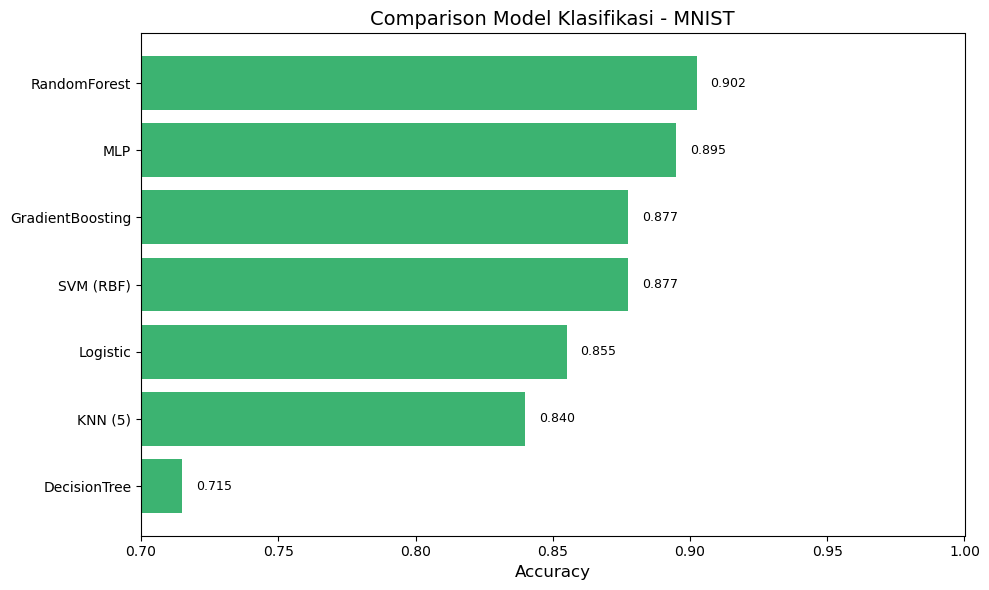

In [16]:
print(df_mnist.to_string(index=False))
plt.figure(figsize=(10, 6))
bars = plt.barh(df_mnist['Model'], df_mnist['Accuracy'], color='mediumseagreen')
plt.xlabel('Accuracy', fontsize=12)
plt.title('Comparison Model Klasifikasi - MNIST', fontsize=14)
plt.xlim(0.7, 1.0)  
plt.gca().invert_yaxis() 
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center', ha='left', fontsize=9)
plt.tight_layout()
plt.show()

## Error Analysis

Total errors: 39 / 400


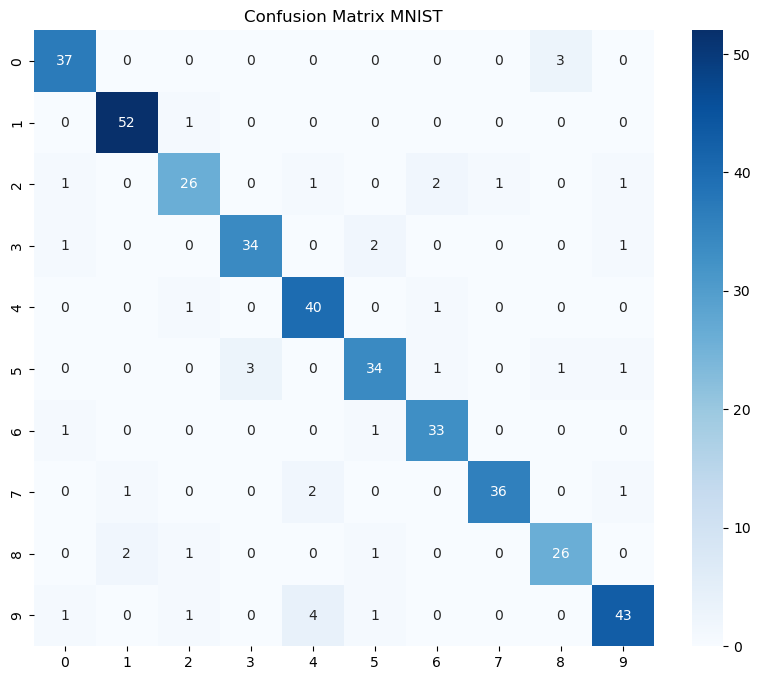

9 → 4: 4 kali
5 → 3: 3 kali
0 → 8: 3 kali
8 → 1: 2 kali
3 → 5: 2 kali


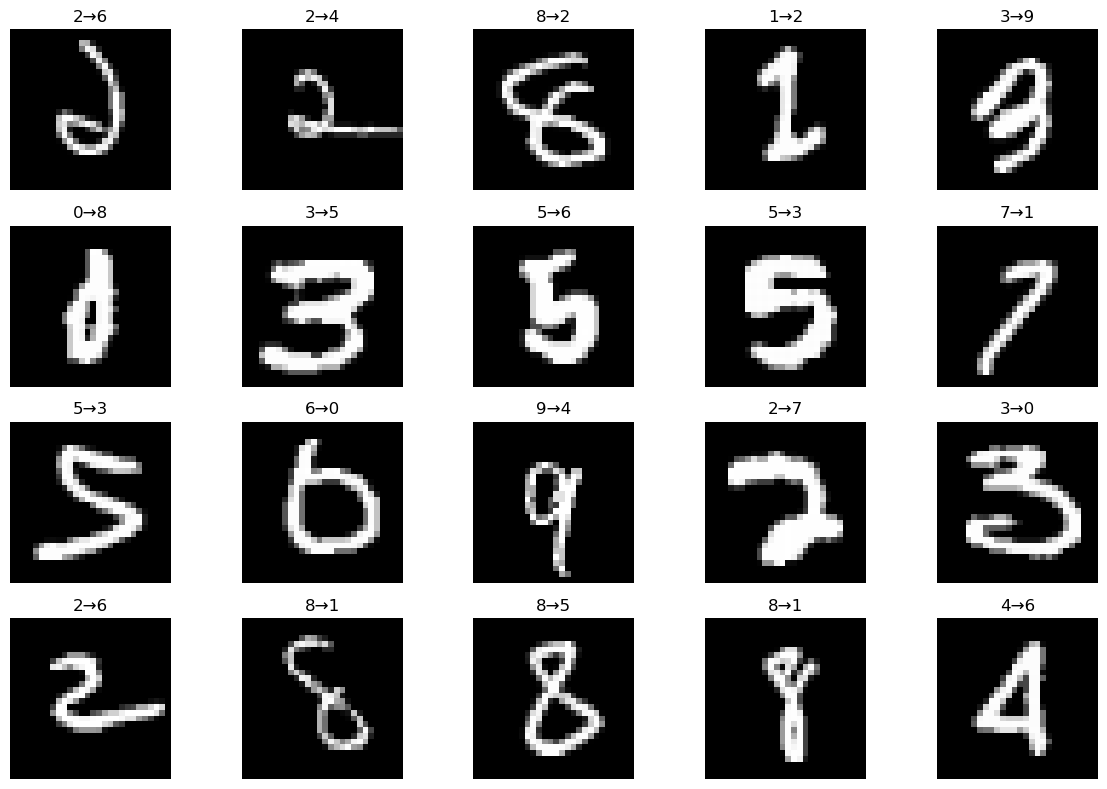

In [17]:
rf_mnist = RandomForestClassifier(n_estimators=50, random_state=42)
rf_mnist.fit(X_train_mnist_scaled, y_train_mnist)
y_pred_mnist = rf_mnist.predict(X_test_mnist_scaled)

mis_idx = np.where(y_test_mnist != y_pred_mnist)[0]
print("Total errors:", len(mis_idx), "/", len(y_test_mnist))

cm = confusion_matrix(y_test_mnist, y_pred_mnist)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix MNIST')
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
pairs = np.argwhere(off > 0)
cnt = off[off > 0]
for i in np.argsort(cnt)[::-1][:5]:
    print(f"{pairs[i][0]} → {pairs[i][1]}: {cnt[i]} kali")

fig, axes = plt.subplots(4,5,figsize=(12,8))
for i, ax in enumerate(axes.ravel()):
    if i < len(mis_idx):
        idx = mis_idx[i]
        ax.imshow(X_test_mnist[idx].reshape(28,28), cmap='gray')
        ax.set_title(f"{y_test_mnist[idx]}→{y_pred_mnist[idx]}")
        ax.axis('off')
plt.tight_layout()
plt.show()

# D. Unsupervised - Clustering

**What is Clustering?**

Clustering is an **unsupervised learning** method. Unlike regression or classification, there is **NO target label (y)**. The goal is simply to **group similar data points** into clusters based on their inherent characteristics, without knowing the correct group names beforehand.

We are using two algorithms here: **KMeans** and **DBSCAN**.

---

**1. KMeans Clustering**

*   **Core Goal**: Partition the data into `K` groups where the points inside each group are as close as possible to the group's center.
*   **The Engine (How it works)**:
    1.  **Initialize**: Choose `K` (here `K=3` because we know Iris has 3 species). Place 3 random points as temporary centroids (centers).
    2.  **Assign (E-step)**: Calculate the distance from every data point to each of the 3 centroids. Assign each point to the closest centroid.
    3.  **Update (M-step)**: Recalculate the position of each centroid. The new centroid is the **mean (average)** of all the data points assigned to that cluster.
    4.  **Repeat**: Iterate steps 2 and 3 until the centroids stop moving (convergence).
*   **Evaluation Metric: Inertia**
    *   Inertia is the sum of the squared distances of every point to its assigned centroid.
    *   `Inertia = Σ (distance from point to centroid)²`
    *   **Smaller Inertia = Tighter and denser clusters**.
*   **Weaknesses of KMeans**:
    *   You must define `K` in advance (if you guess wrong, the result is bad).
    *   Very sensitive to outliers (an extreme point can drag the centroid toward it).
    *   Can only create **spherical/ball-shaped** clusters because it relies on Euclidean distance.

---

**2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

*   **Core Goal**: Group points based on **density** (how tightly packed they are). There is **no need to specify the number of clusters**.
*   **The Engine (How it works)**:
    1.  Define 2 parameters:
        *   `eps` (epsilon) = The radius around a point.
        *   `min_samples` = The minimum number of points required inside the `eps` radius for that point to be considered a "dense" area.
    2.  **Core Point**: A point that has at least `min_samples` neighbors within `eps`. These are the seeds of clusters.
    3.  **Border Point**: A point that is close to a Core Point, but does not have enough neighbors to be a Core Point itself.
    4.  **Noise / Outlier**: A point that is neither a Core Point nor a Border Point. These are labeled as `-1`.
    5.  Clusters are formed by connecting Core Points that are within `eps` distance of each other (transitively).
*   **Parameters used**:
    *   `eps = 0.5` : The search radius.
    *   `min_samples = 5` : A point needs at least 5 neighbors in that radius to become a core point.
*   **Strengths of DBSCAN**:
    *   No need to predefine the number of clusters.
    *   Can automatically detect outliers.
    *   Can form **arbitrary shapes** (not just spherical).
*   **Weaknesses of DBSCAN**:
    *   Highly sensitive to the `eps` and `min_samples` settings.
    *   Struggles if the dataset has significantly varying densities across different areas.


## KMeans

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_iris_scaled)
inertia = kmeans.inertia_

C:\Users\FARUQ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## DBScan

In [19]:
dbscan = DBSCAN(eps=0.5,min_samples=5)
labels_dbscan=dbscan.fit_predict(X_iris_scaled)
n_clusters=len(set(labels_dbscan))-(1 if -1 in labels_dbscan else 0)
n_outliers=np.sum(labels_dbscan == -1)

##  Result and Visualization 

KMeans Inertia : 139.82
DBSCAN: 2 cluster, 34 outlier


C:\Users\FARUQ\AppData\Local\Temp\ipykernel_21796\2002340964.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(X_pca[labels_dbscan == label, 0], X_pca[labels_dbscan == label, 1],


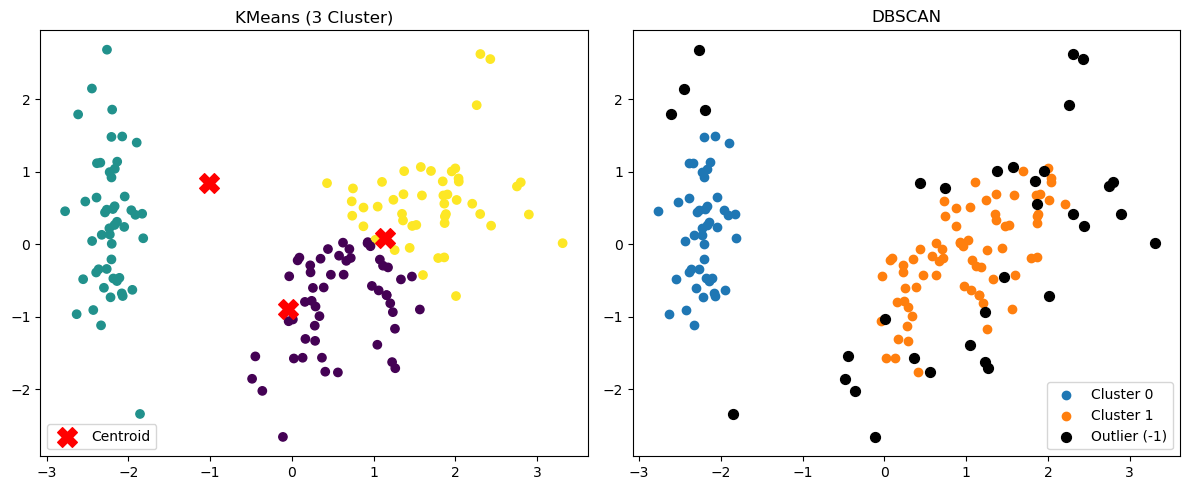

In [20]:
print(f"KMeans Inertia : {inertia:.2f}")
print(f"DBSCAN: {n_clusters} cluster, {n_outliers} outlier")

# Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='viridis')
ax1.set_title('KMeans (3 Cluster)')
ax1.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            c='red', marker='X', s=200, label='Centroid')
ax1.legend()

for label in set(labels_dbscan):
    if label == -1:
        ax2.scatter(X_pca[labels_dbscan == -1, 0], X_pca[labels_dbscan == -1, 1], 
                    c='black', s=50, label='Outlier (-1)')
    else:
        ax2.scatter(X_pca[labels_dbscan == label, 0], X_pca[labels_dbscan == label, 1], 
                    cmap='plasma', label=f'Cluster {label}')
ax2.legend()
ax2.set_title('DBSCAN')
plt.tight_layout()

# Dimensionality Reduction

Dimensionality reduction constitutes a fundamental preprocessing step in the analysis of high-dimensional data, particularly in domains such as image processing, where each observation is represented by a large number of features (e.g., 784 pixels in the MNIST dataset). The primary objective is to project the data into a lower-dimensional space—typically two or three dimensions—while preserving the intrinsic structure of the data as faithfully as possible. This projection enables visualisation, exploratory analysis, and often serves as a precursor to further modelling. Two widely adopted techniques for this purpose are Principal Component Analysis (PCA) and t-Distributed Stochastic Neighbor Embedding (t-SNE), each rooted in distinct theoretical frameworks and exhibiting complementary strengths and limitations.

---

**Principal Component Analysis (PCA)**

PCA is a linear, deterministic method that seeks to identify the orthogonal directions (principal components) along which the variance of the data is maximised. Conceptually, the algorithm proceeds as follows. First, the data matrix is standardised to zero mean and unit variance per feature, ensuring that variables with larger scales do not dominate the variance structure. Subsequently, the covariance matrix of the standardised data is computed, capturing the pairwise covariances among all features. An eigendecomposition of this covariance matrix yields a set of eigenvectors and corresponding eigenvalues. Each eigenvector defines a principal component—a linear combination of the original features—and its eigenvalue quantifies the amount of variance explained by that component. The eigenvectors are sorted in descending order of their eigenvalues, and the top k eigenvectors are selected to form a projection matrix. Finally, the original data is projected onto this reduced subspace by matrix multiplication, resulting in a k‑dimensional representation.

PCA is highly efficient, both computationally and interpretatively, as it provides a clear ranking of components by their explanatory power. The explained variance ratio, defined as the proportion of total variance captured by each component, offers a quantitative measure of information retention. However, PCA is inherently linear; it assumes that the underlying structure of the data lies on a linear subspace. Consequently, it may fail to capture complex, non-linear manifolds, leading to overlapping clusters in the visualisation—a phenomenon observed when applying PCA to MNIST, where digits such as 3 and 8 remain intermixed due to their linear proximity in pixel space.

---

**t-Distributed Stochastic Neighbor Embedding (t-SNE)**

t-SNE is a non-linear, probabilistic technique specifically designed for visualising high-dimensional data in two or three dimensions. Unlike PCA, which preserves global variance, t-SNE focuses on preserving local similarities—that is, the neighbourhood structure of the data. The algorithm operates as follows. In the high-dimensional space, for each pair of points i and j, a conditional probability p_j|i is computed, representing the likelihood that point i would choose point j as its neighbour, assuming a Gaussian distribution centred at i. These conditional probabilities are symmetrised to obtain a joint probability distribution P over all pairs, capturing the local affinity structure of the original data. In the low-dimensional embedding, a similar probability distribution Q is defined using a Student-t distribution with one degree of freedom (which has heavier tails than a Gaussian). This choice mitigates the “crowding problem” by allowing dissimilar points to be placed farther apart in the embedding. The objective of t-SNE is to minimise the Kullback–Leibler (KL) divergence between P and Q, which measures the information loss when Q approximates P. This minimisation is performed via gradient descent, iteratively adjusting the positions of points in the low-dimensional space until convergence.

The most critical hyperparameter in t-SNE is perplexity, which can be interpreted as a smooth measure of the effective number of neighbours considered for each point. Typical values range from 5 to 50, with higher values emphasising global structure and lower values focusing on local details. t-SNE is stochastic; different initialisations or random seeds can yield different embeddings, hence the use of a fixed random state for reproducibility.

t-SNE excels at revealing cluster structures that are not linearly separable. In the context of MNIST, it produces well-separated clusters for each digit, clearly distinguishing visually similar digits (e.g., 3 and 8) by placing them in neighbouring but distinct regions of the embedding space. The primary drawbacks of t-SNE are its computational cost—scaling quadratically with the number of samples (O(n²))—and its inability to project new out-of-sample data points without recomputing the entire embedding.

---

**Comparative Discussion and Practical Considerations**

The choice between PCA and t-SNE hinges on the analytical objective. PCA is suitable when computational efficiency and interpretability are paramount, and when the underlying data structure is approximately linear. It also provides a projection matrix that can be applied to new data, making it useful for feature extraction in downstream modelling pipelines. t-SNE, on the other hand, is the method of choice for visualisation of non-linear structures, particularly when the dataset is modest in size (typically a few thousand points) and the primary goal is exploratory data analysis. In such cases, t-SNE reveals groupings that PCA cannot uncover, as evidenced by the stark contrast between the entangled PCA projection of MNIST and the tightly clustered t-SNE embedding.

In practice, a common workflow involves applying PCA to reduce the dimensionality to a moderate level (e.g., 50 dimensions) before running t-SNE, thereby accelerating the computation while preserving most of the relevant structure. This hybrid approach leverages the speed of PCA and the fidelity of t-SNE.

In summary, PCA offers a linear, deterministic, and efficient reduction that preserves global variance, while t-SNE provides a non-linear, probabilistic embedding that excels at preserving local neighbourhoods. Both are indispensable tools in the data scientist’s repertoire, and their judicious application depends on the specific requirements of the analysis at hand. The visual results from the MNIST experiment confirm that t-SNE, despite its computational overhead, yields a substantially more interpretable representation of the data, highlighting its superiority for visualisation tasks involving complex, high-dimensional patterns.

## Principal Component Analysis (PCA)

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_mnist_scaled)

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

In [22]:
tsne = TSNE(n_components=2,perplexity=30,random_state=42)
X_tsne = tsne.fit_transform(X_train_mnist_scaled)

## Visualization 

PCA explained variance: 10.98%


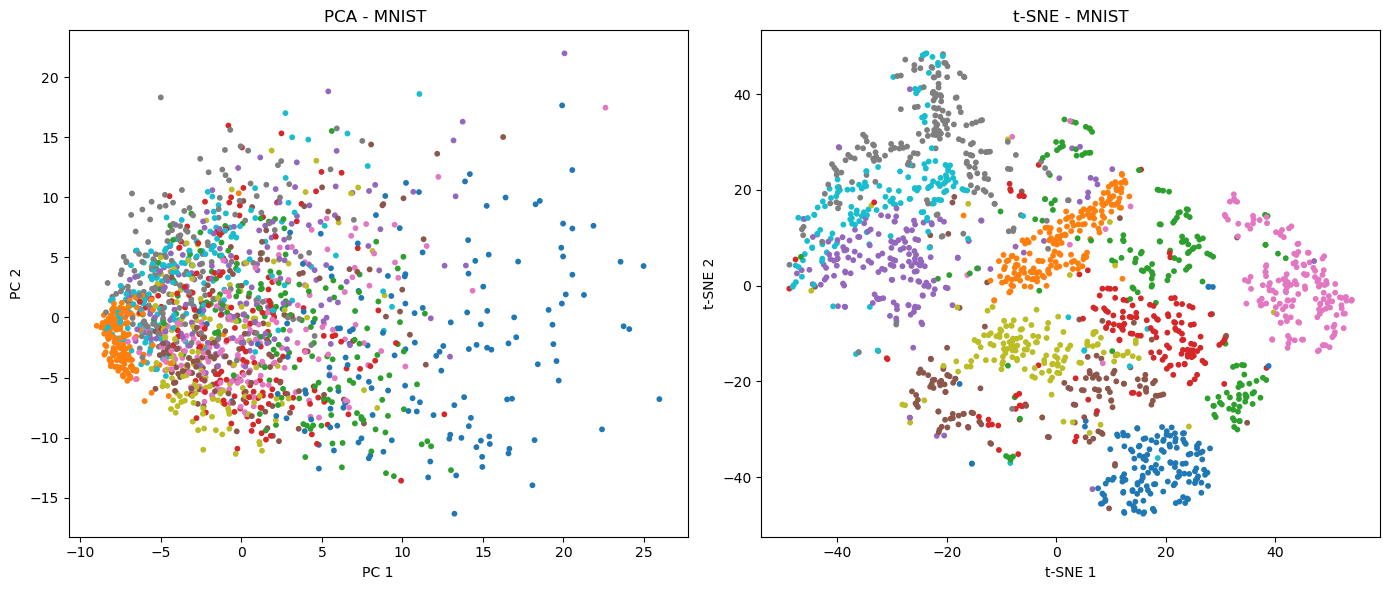

In [23]:
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_pca[:,0], X_pca[:,1], c=y_train_mnist, cmap='tab10', s=10)
ax1.set_title('PCA - MNIST ')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')

ax2.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train_mnist, cmap='tab10', s=10)
ax2.set_title('t-SNE - MNIST')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

# Model and Feature Selection

## Model Selection 

In [24]:
param_grid = {
    'n_estimators': [10, 50, 100],# tree amount
    'max_depth': [3, 5, None],# tree depth
    'min_samples_split': [2, 5]# minimum sampel to split
}

model_selection = RandomForestClassifier(random_state=42)

#Grid Search
grid = GridSearchCV(model_selection, param_grid, cv=3, scoring='accuracy') #try all combinations 
grid.fit(X_iris, y_iris)
print(f"GridSearch - Best Params: {grid.best_params_}")
print(f"GridSearch - Best Score: {grid.best_score_:.4f}")

#Randomized Search
random_search = RandomizedSearchCV(model_selection, param_grid, n_iter=5, cv=3, random_state=42) #try with iteration = n_iter
random_search.fit(X_iris, y_iris)
print(f"\nRandomSearch - Best Params: {random_search.best_params_}")
print(f"RandomSearch - Best Score: {random_search.best_score_:.4f}")

#cv=crossvalidations (to reduce the overfitting)

GridSearch - Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 50}
GridSearch - Best Score: 0.9733

RandomSearch - Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 3}
RandomSearch - Best Score: 0.9667


Model selection is a critical stage in the machine learning pipeline that involves identifying the optimal hyperparameter configuration for a given learning algorithm. Unlike model parameters, which are learned directly from the training data, hyperparameters are specified prior to training and govern fundamental aspects of the model's architecture, capacity, and regularisation behaviour. Examples include the number of trees in a random forest (`n_estimators`), the maximum tree depth (`max_depth`), the regularisation strength in linear models (`alpha` in Lasso or Ridge), and the kernel parameters in support vector machines (`C` and `gamma`). The choice of hyperparameters exerts a profound influence on the model's generalisation performance, and manual tuning is often infeasible due to the combinatorial explosion of possible configurations. Hyperparameter optimisation is therefore formalised as the task of finding the set of hyperparameters that minimises the expected generalisation error. Since the true data distribution is unknown, this objective is approximated using cross-validation performance on a finite training set.

---

**GridSearchCV: Exhaustive Search**

GridSearchCV performs an exhaustive search over a user-specified grid of hyperparameter values. Given a set of hyperparameters with respective candidate sets, the algorithm evaluates every possible combination by iterating through the Cartesian product of these sets. For each combination, it performs K-fold cross-validation: the training data is partitioned into K disjoint folds, and the model is trained on K minus 1 folds and validated on the held-out fold. This process is repeated K times, with each fold serving as the validation set exactly once. The mean validation score across the K folds serves as the estimate of the generalisation performance for that particular hyperparameter combination. After evaluating all combinations, the combination achieving the highest mean score is selected as the optimal configuration.

**Key Parameters:**
- `param_grid`: A dictionary that maps hyperparameter names to lists of candidate values to be explored.
- `cv`: The number of cross-validation folds, typically set to 3, 5, or 10. Higher values reduce variance in the performance estimate but increase computational cost.
- `scoring`: The evaluation metric used to assess performance. For classification tasks, common choices include 'accuracy', 'precision', 'recall', and 'f1'. For regression tasks, metrics such as 'neg_mean_squared_error' or 'r2' are frequently employed.
- `n_jobs`: The number of parallel jobs to run. Setting `n_jobs = -1` utilises all available processor cores.
- `verbose`: Controls the amount of output generated during the search process. Higher values provide more detailed progress updates.

**Strengths and Limitations:**

GridSearchCV is deterministic and guarantees the identification of the optimal combination within the specified grid. This property ensures reproducibility and provides a clear understanding of the search space. However, its computational cost grows exponentially with the number of hyperparameters and the size of their candidate sets. Specifically, the total number of evaluations is the product of the sizes of all candidate sets, multiplied by the number of cross-validation folds (K). Consequently, GridSearchCV becomes prohibitively expensive for high-dimensional hyperparameter spaces or large datasets, where each model fit is computationally intensive.

**Practical Considerations:**
- GridSearchCV is most suitable when the hyperparameter space is small, typically involving two to three hyperparameters with a limited number of candidate values.
- The search grid should be designed carefully to balance exploration and computational feasibility. Coarse grids with wide value ranges can be refined iteratively based on intermediate results.

---

**RandomizedSearchCV: Stochastic Sampling**

RandomizedSearchCV addresses the computational bottleneck of GridSearchCV by adopting a stochastic sampling strategy. Instead of exhaustively enumerating all possible combinations, it randomly samples hyperparameter values from specified distributions or lists for a predefined number of iterations. The user specifies the total number of iterations (`n_iter`), and each iteration randomly selects one value for each hyperparameter. The model is evaluated using cross-validation, and the best combination observed across the iterations is retained.

**Key Parameters:**
- `param_distributions`: A dictionary that maps hyperparameter names to distributions, such as uniform, log-uniform, or integer uniform, or to lists of candidate values. Using continuous distributions allows for more granular exploration of the hyperparameter space compared to discrete grids.
- `n_iter`: The number of random combinations to evaluate. This parameter controls the trade-off between computational cost and the likelihood of finding optimal configurations.
- `cv`: The number of cross-validation folds, with semantics identical to GridSearchCV.
- `scoring`: The evaluation metric, as described for GridSearchCV.
- `random_state`: A fixed seed for the random number generator, ensuring reproducibility of the sampling process.
- `n_jobs` and `verbose`: As in GridSearchCV.

**Strengths and Limitations:**

RandomizedSearchCV drastically reduces computational cost by exploring only a fraction of the hyperparameter space. Empirical studies have demonstrated that random search is often more efficient than grid search, as it samples a broader range of values and is less likely to miss optimal regions in high-dimensional spaces. This advantage arises because random search does not restrict evaluation to fixed grid points, allowing it to explore the hyperparameter space more continuously. However, RandomizedSearchCV does not guarantee global optimality, as the optimal configuration may not be sampled within the allocated number of iterations.


## Advanced Hyperparameter Tuning

In [25]:
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
rf = RandomForestRegressor(random_state=42)
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train_scaled, y_train_housing)
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test_housing, y_pred_rf))
r2_rf = r2_score(y_test_housing, y_pred_rf)

print("RF best params:", rf_search.best_params_)
print("RF RMSE:", np.sqrt(mean_squared_error(y_test_housing, rf_search.best_estimator_.predict(X_test_scaled))))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RF best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
RF RMSE: 0.4906233434560335


## Feature Selection

In [26]:
model_selection = RandomForestRegressor(random_state=42)
selector = RFE(estimator=model_selection, n_features_to_select=4) 
selector.fit(X_train_scaled, y_train_housing)

support = selector.support_  
selected_features = np.array(housing.feature_names)[support]
print(f"Selected Features: {selected_features}")

X_train_sel = X_train_scaled[:, support]
X_test_sel = X_test_scaled[:, support]

rf_sel = RandomForestRegressor(n_estimators=50, random_state=42)
rf_sel.fit(X_train_sel, y_train_housing)
r2_sel = r2_score(y_test_housing, rf_sel.predict(X_test_sel))

print(f"R² with 4 best features: {r2_sel:.4f}")

Selected Features: ['MedInc' 'AveOccup' 'Latitude' 'Longitude']
R² with 4 best features: 0.8022


Feature selection is a fundamental preprocessing step in machine learning that involves identifying a subset of relevant features from the original feature set for model construction. The elimination of irrelevant, redundant, or noisy features serves multiple purposes: (i) reducing the risk of overfitting by removing variables that do not contribute meaningful signal, (ii) improving model interpretability by simplifying the feature space, (iii) decreasing computational costs associated with training and inference, and (iv) enhancing generalisation performance by focusing the learning algorithm on the most informative predictors. Given a dataset with a large number of features, denoted as p, the objective is to find a subset S of size m, where m is smaller than p, that maximises the model's predictive performance as measured by a suitable evaluation metric. This problem is inherently combinatorial, as the number of possible subsets grows exponentially with p, necessitating the use of heuristic or iterative selection algorithms.

---

**Recursive Feature Elimination (RFE): Algorithmic Foundation**

Recursive Feature Elimination (RFE) is a backward selection algorithm that iteratively removes features based on their importance weights, as determined by a base estimator. The algorithm operates through a systematic recursive process, which can be formalised as follows:

1. **Initialisation**: Begin with the full set of available features.
2. **Model Training**: Train the base estimator on the current feature set.
3. **Importance Scoring**: Extract feature importance scores from the trained estimator. For linear models, importance is derived from the absolute values of the coefficients; for tree-based ensembles, it is obtained from the feature importances, which are typically computed as the reduction in impurity (e.g., Gini impurity or variance reduction) averaged across all trees.
4. **Elimination**: Identify the least important feature, or a specified number of least important features, based on the importance scores and remove them from the current feature set.
5. **Recursion**: Repeat steps 2 through 4 until the desired number of features, specified by the parameter `n_features_to_select`, remains.

The term "recursive" refers to the fact that the base estimator is refitted at each iteration, allowing the importance scores to be reassessed within the context of the reduced feature space. This reassessment is critical, as the relevance of a feature can change when correlated features are removed.

---

**Key Parameters**

- `estimator`: A supervised learning model that provides feature importance scores or coefficients. Suitable estimators include `RandomForestRegressor`, `RandomForestClassifier`, `LinearRegression`, `Lasso`, `LogisticRegression`, and `GradientBoostingRegressor`. The choice of estimator directly influences the quality of the feature ranking, as different models compute importance scores according to distinct criteria.

- `n_features_to_select`: The number of features to retain at the conclusion of the elimination process. This parameter determines the dimensionality of the reduced feature set and should be selected based on the desired trade-off between model complexity and performance.

- `step`: The number of features to remove at each iteration. The default value is 1, meaning one feature is eliminated per iteration. A value greater than 1 accelerates the process by removing multiple features simultaneously; however, this may reduce the optimality of the final subset, as it increases the risk of discarding potentially important features in bulk.

---

**Theoretical Justification and Mathematical Basis**

RFE operates under the implicit assumption that the feature importance scores provided by the base estimator are reliable indicators of each feature's contribution to the model's predictive performance. For linear models, the magnitude of the coefficient for a given feature reflects its marginal contribution to the target variable, assuming the features are standardised. For tree-based models, the feature importance is derived from the total reduction in the impurity criterion (e.g., mean squared error for regression or Gini impurity for classification) achieved by splits on that feature, averaged across all trees in the ensemble. This reduction is a measure of how much the feature contributes to reducing the uncertainty in the predictions.

By iteratively eliminating features with the lowest importance scores and refitting the model, RFE approximates the optimal feature subset with a computational complexity that scales quadratically with the number of features in the worst case, as each iteration requires retraining the model on a progressively smaller feature set. While this is more computationally expensive than univariate feature selection methods, it has the advantage of accounting for feature interactions, as the importance of a feature is evaluated within the context of the other features present in the model.

---

**Strengths and Limitations**

**Strengths:**

1. **Interaction Awareness**: Unlike univariate selection methods that evaluate each feature independently, RFE considers feature interactions because importance scores are computed in the presence of all other features currently retained in the model. This allows RFE to capture synergistic effects among features.

2. **Flexibility**: RFE can be applied with any estimator that provides a feature importance ranking, making it adaptable to a wide range of models and problem types.

3. **Principled Elimination**: The recursive nature of the algorithm ensures that the elimination process is grounded in the model's performance, providing a more systematic approach to feature selection compared to simple thresholding based on statistical tests.

**Limitations:**

1. **Computational Cost**: RFE requires multiple model trainings, each on a different subset of features, which can be computationally expensive for large feature sets and complex estimators.

2. **Dependence on Estimator**: The quality of the feature subset selected by RFE is contingent on the suitability of the base estimator. An estimator that produces unreliable importance scores will lead to suboptimal feature selection.

3. **Stability**: RFE can be sensitive to noise in the data, particularly when the feature set contains highly correlated or redundant predictors. In such cases, the selection of features may vary across different runs or data splits.

4. **Incompatibility with Certain Models**: RFE cannot be applied with estimators that do not provide feature importance or coefficient values, such as K-Nearest Neighbours, Naive Bayes, or other models that lack an intrinsic feature ranking mechanism. This limitation arises because the elimination criterion relies on a quantitative ranking of features, which is not available from these models.

---

**Methodological Recommendations**

1. **Choice of Estimator**: When applying RFE, it is advisable to select an estimator with robust importance metrics. Random Forest and Gradient Boosting are generally preferred for tabular data due to their ability to capture non-linear relationships and interactions. For linear relationships, Lasso regression provides a sparse solution with built-in feature selection and can be used directly; however, when used within RFE, it offers an alternative ranking criterion based on coefficient magnitudes.

2. **Cross-Validation for Selection**: To avoid overfitting and to determine the optimal number of features automatically, practitioners should consider using `RFECV`, an extension of RFE that incorporates cross-validation. This variant evaluates the model performance at each stage of the elimination process and selects the number of features that yields the highest cross-validated score, thereby eliminating the need to specify `n_features_to_select` manually.

3. **Combination with Dimensionality Reduction**: For datasets with a very large number of features, it may be beneficial to first apply a dimensionality reduction technique, such as PCA or feature hashing, to reduce the feature space to a manageable size before applying RFE. This approach accelerates the RFE process while still capturing the most relevant signal.

4. **Standardisation and Preprocessing**: Before applying RFE, especially when using linear models, it is crucial to standardise the features to ensure that the coefficients are comparable. Failure to do so can result in misleading importance rankings, as features with larger scales will dominate the coefficient magnitudes.


# Conclusion

**Synthesis and Final Remarks**

This notebook has presented a structured and exhaustive exploration of the scikit-learn ecosystem, systematically demonstrating the core components of a complete machine learning workflow. Beginning with data loading and preprocessing, advancing through supervised learning tasks—both regression and classification—and extending to unsupervised learning, dimensionality reduction, hyperparameter optimisation, and feature selection, the exposition has provided a cohesive framework for understanding and implementing machine learning pipelines in Python. The datasets employed—California Housing, Iris, and MNIST—were deliberately selected to represent increasing levels of complexity, ranging from small-scale, well-structured tabular data to high-dimensional image data, thereby illustrating the generalisability and limitations of various algorithms.

The regression experiments on the California Housing dataset revealed the superiority of tree-based ensemble methods, particularly Gradient Boosting and Random Forest, which consistently outperformed linear models due to their ability to capture non-linear interactions and saturation effects inherent in real-world economic data. The comparative analysis underscored the importance of model selection, as default hyperparameter configurations for methods such as Support Vector Regression often yielded suboptimal performance without careful tuning.

In the classification tasks, the Iris dataset, while historically significant, proved to be relatively trivial for modern machine learning algorithms, with nearly all models achieving near-perfect accuracy. This observation highlights the necessity of more challenging benchmarks such as MNIST, where the non-linear and high-dimensional nature of pixel data revealed the distinct advantages of kernel-based methods and ensemble approaches. The visualisation of MNIST using Principal Component Analysis and t-Distributed Stochastic Neighbor Embedding illustrated the critical distinction between linear and non-linear dimensionality reduction techniques, with t-SNE producing substantially more interpretable cluster structures.

The unsupervised learning components, comprising KMeans clustering and DBSCAN, demonstrated the utility of density-based approaches for outlier detection and the importance of parameter selection in achieving meaningful groupings. The subsequent sections on hyperparameter optimisation and feature selection addressed the practical challenges of model refinement, balancing computational cost, generalisation performance, and interpretability.

Collectively, this notebook serves as both an instructional resource and a practical reference for practitioners, emphasising the methodological rigour required in experimental design, evaluation, and interpretation of machine learning results. The code, accompanied by thorough documentation and theoretical explanations, provides a foundation that can be adapted to a wide array of predictive modelling tasks.

---

**Key Takeaways**

1. **Preprocessing and Data Integrity**: Standardisation, imputation, and encoding are indispensable steps that directly influence model performance. The principle of fitting preprocessing parameters exclusively on training data and applying the same transformation to test data is essential to prevent data leakage.

2. **Model Selection and Evaluation**: No single algorithm universally outperforms others; the optimal choice depends on the nature of the data, the problem domain, and the available computational resources. Cross-validation and appropriate evaluation metrics are critical for reliable performance assessment.

3. **Ensemble Methods**: Tree-based ensembles, particularly Random Forest and Gradient Boosting, consistently demonstrate superior performance on tabular data due to their flexibility and robustness, often outperforming linear and kernel-based models without extensive hyperparameter tuning.

4. **Dimensionality and Visualisation**: Techniques such as PCA and t-SNE are essential for interpreting high-dimensional data, with t-SNE offering superior visualisation capabilities at the cost of increased computational overhead and stochastic variability.

5. **Hyperparameter Optimisation**: GridSearchCV and RandomizedSearchCV provide systematic approaches to hyperparameter tuning, with the latter offering a computationally efficient alternative for high-dimensional search spaces.

6. **Feature Selection**: Recursive Feature Elimination offers a principled method for reducing dimensionality, enhancing interpretability, and mitigating overfitting, contingent on the availability of reliable feature importance metrics.

---

**Implementation Insights and Best Practices**

- **Reproducibility**: The consistent use of fixed random seeds (`random_state = 42`) ensures reproducibility across runs, a fundamental requirement for scientific research and collaborative development.

- **Computational Efficiency**: Parallelisation through `n_jobs = -1` accelerates training and cross-validation processes, particularly for ensemble methods and grid searches.

- **Pipeline Integration**: While not explicitly implemented in all sections, the use of `Pipeline` and `ColumnTransformer` is recommended for production-grade applications to ensure consistent preprocessing across training and inference phases.

- **Error Handling**: The inclusion of try-except blocks during model evaluation prevents complete workflow failures and provides informative diagnostics for debugging.

---

**Future Directions and Extensions**

While this notebook provides a comprehensive foundation, several extensions are recommended for advanced applications:

1. **Deep Learning Integration**: For image, text, and audio data, neural network architectures implemented in TensorFlow or PyTorch would offer superior performance, complementing the scikit-learn models demonstrated here.

2. **Time Series Forecasting**: Incorporating temporal dependencies through specialised models, such as ARIMA, Prophet, or LSTM networks, would address a broader class of predictive problems.

3. **Automated Machine Learning (AutoML)**: Integration of libraries such as AutoGluon, TPOT, or H2O.ai could further streamline hyperparameter optimisation and model selection, reducing manual intervention.

4. **Model Interpretability**: Tools such as SHAP, LIME, and ELI5 could be incorporated to provide local and global explanations of model predictions, enhancing trust and transparency, particularly in regulated industries.

5. **Deployment and Monitoring**: The transition from development to production requires robust deployment frameworks, such as Flask, FastAPI, or MLflow, along with continuous monitoring of model performance and data drift.

---

**Concluding Statement**

This comprehensive exploration of machine learning with scikit-learn demonstrates the breadth and depth of the library's capabilities, from foundational data preprocessing to advanced model selection and evaluation. The systematic approach adopted throughout this notebook not only facilitates the mastery of specific techniques but also cultivates a disciplined, scientific mindset essential for effective machine learning practice. As the field continues to evolve, the principles of rigorous experimental design, reproducibility, and careful evaluation remain paramount. The code, documentation, and theoretical exposition provided herein constitute a valuable resource for both novice and experienced practitioners, serving as a foundation for further exploration and innovation in data science and artificial intelligence.

---

**Acknowledgements**

This notebook synthesises concepts from the scikit-learn documentation, numerous open-source contributions, and foundational texts in machine learning and statistical modelling. The author acknowledges the invaluable contributions of the open-source community and the developers of the libraries employed throughout this work.

---

**Final Note**

The notebook is intended for educational and reference purposes. While the code has been tested and verified, users are encouraged to adapt and extend the examples to suit their specific requirements. Contributions, feedback, and collaborations are welcome.